<a href="https://colab.research.google.com/github/flameFalconxD/aser-beam-profiling---safety-analysis-kvant/blob/main/Laser_Beam_Profiling_KVANT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

KVANT Atom 42 Parameters (for RGB comparison)


In [ ]:
lasers = {                      #wavelength of each laser module
    "Red (638 nm)": 638e-9,
    "Green (525 nm)": 525e-9,
    "Blue (455 nm)": 455e-9
}
powers = {                      #power of each laser module
    "Red (638 nm)": 9,
    "Green (525 nm)": 13,
    "Blue (455 nm)": 20
}
w0 = 3.5e-3   # 7 mm diameter → 3.5 mm radius

z = np.linspace(0.01, 50, 800) #At z = 0, irradiance can be unrealistically high

MPE = 2500  # Safety threshold (W/m^2)

Plotting Beam Expansion (RGB)

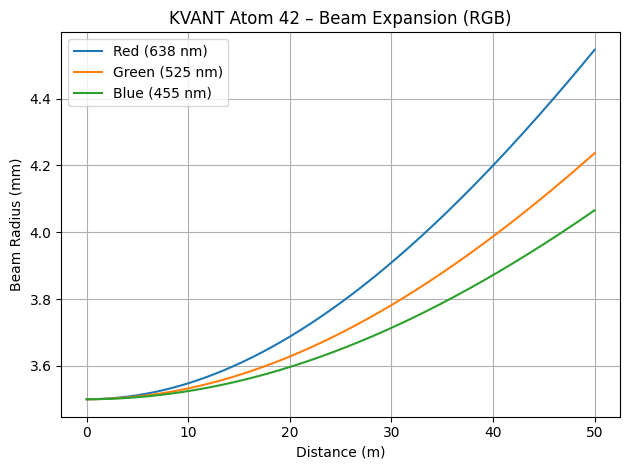

In [ ]:
plt.figure()

for label, wavelength in lasers.items():
    zR = np.pi * w0**2 / wavelength
    wz = w0 * np.sqrt(1 + (z / zR)**2)
    plt.plot(z, wz * 1e3, label=label)

plt.xlabel("Distance (m)")
plt.ylabel("Beam Radius (mm)")
plt.title("KVANT Atom 42 – Beam Expansion (RGB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("beam_expansion.png")
plt.show()

Plotting Irradiance (Log Scale)

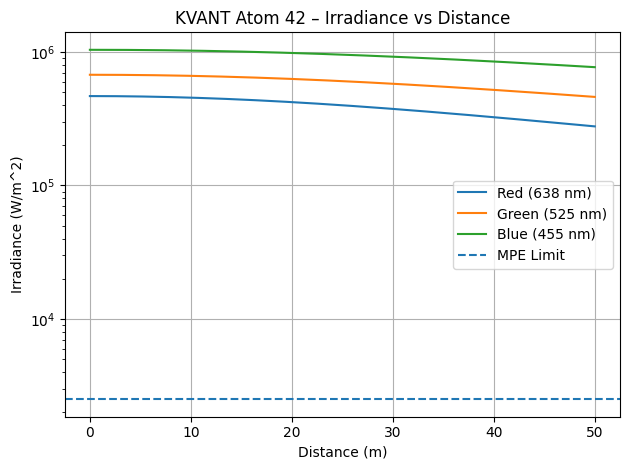

In [ ]:
plt.figure()

for label, wavelength in lasers.items():
    power = powers[label]
    zR = np.pi * w0**2 / wavelength
    wz = w0 * np.sqrt(1 + (z / zR)**2)
    irradiance = (2 * power) / (np.pi * wz**2)
    plt.plot(z, irradiance, label=label)

plt.axhline(MPE, linestyle='--', label="MPE Limit")

plt.xlabel("Distance (m)")
plt.ylabel("Irradiance (W/m^2)")
plt.yscale('log')
plt.title("KVANT Atom 42 – Irradiance vs Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("irradiance_log.png")
plt.show()

Safety Zone Visualization (For Green Laser)

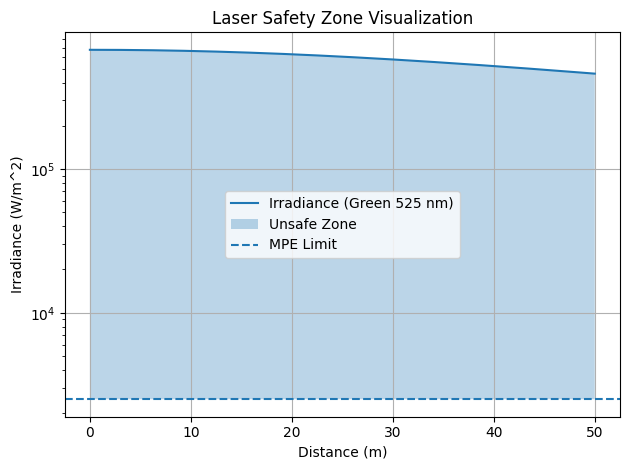

In [ ]:
wavelength = 525e-9
power = 13

zR = np.pi * w0**2 / wavelength
wz = w0 * np.sqrt(1 + (z / zR)**2)
irradiance = (2 * power) / (np.pi * wz**2)

plt.figure()
plt.plot(z, irradiance, label="Irradiance (Green 525 nm)")

plt.fill_between(z, irradiance, MPE,
                 where=(irradiance > MPE),
                 alpha=0.3,
                 label="Unsafe Zone")

plt.axhline(MPE, linestyle='--', label="MPE Limit")

plt.xlabel("Distance (m)")
plt.ylabel("Irradiance (W/m^2)")
plt.yscale('log')
plt.title("Laser Safety Zone Visualization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("safety_zone.png")
plt.show()

Beam Divergence Angle

In [ ]:
theta = wavelength / (np.pi * w0)

print(f"Beam Divergence: {theta*1000:.3f} mrad")

Beam Divergence: 0.048 mrad


IEC Classification

In [ ]:
def classify_laser(irradiance, MPE):
    max_I = np.max(irradiance)

    if max_I < MPE:
        return "Class 1"
    elif max_I < 5 * MPE:
        return "Class 2 / 3R"
    elif max_I < 500 * MPE:
        return "Class 3B"
    else:
        return "Class 4"

classification = classify_laser(irradiance, MPE)

print("\n--- IEC Safety Classification ---")
print(f"Max Irradiance: {np.max(irradiance):.2e} W/m^2")
print(f"Estimated Class: {classification}")


--- IEC Safety Classification ---
Max Irradiance: 6.76e+05 W/m^2
Estimated Class: Class 3B
